In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# Locate data directory robustly across Jupyter, VS Code, and MCP
candidates = [
    Path("../data"),
    Path("data"),
    Path.cwd() / "data",
    Path.home() / "Desktop" / "NovĂˇ sloĹľka (2)" / "fundamentals_of_data_science" / "data",
    Path(r"C:\Users\stynz\Desktop\NOVSLO~2\fundamentals_of_data_science\data")
]
data_dir = next((p for p in candidates if (p / "conflict_clean.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError("Could not locate data directory.")
print(f"Data directory: {data_dir.resolve()}")

Data directory: C:\Users\stynz\Desktop\Nová složka (2)\fundamentals_of_data_science\data


In [6]:
df_deaths = pd.read_excel(data_dir / 'PRIO Battle Deaths Dataset 31.xls')
df_deaths.head(3)

,id,year,bdeadlow,bdeadhig,bdeadbes,annualdata,source,bdversion,location,sidea,sidea2nd,sideb,sideb2nd,incomp,terr,int,cumint,type,startdate,startprec,startdate2,startprec2,epend,ependdate,ependprec,gwnoa,gwnoa2nd,gwnob,gwnob2nd,gwnoloc,region,version
0,1,1946,1000,9999,1000,2,1,3.1,Bolivia,Bolivia,NaN,Popular Revolutionary Movement,NaN,2,NaN,2,1,3,1946-06-01,4,1946-06-01,4,1,1946-07-21,-99.0,145,NaN,NaN,NaN,145,5,2009-4
1,1,1952,450,3000,-999,2,1,3.1,Bolivia,Bolivia,NaN,MNR,NaN,2,NaN,1,1,3,1946-06-01,4,1952-04-09,1,1,1952-04-12,-99.0,145,NaN,NaN,NaN,145,5,2009-4
2,1,1967,25,999,82,2,1,3.1,Bolivia,Bolivia,NaN,ELN,NaN,2,NaN,1,1,3,1946-06-01,4,1967-03-01,3,1,1967-10-16,-99.0,145,NaN,NaN,NaN,145,5,2009-4


In [7]:
conflict = pd.read_csv(data_dir / 'conflict_clean.csv')
conflict = conflict[conflict['year'] <= 2008]
conflict.head(3)

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,year,intensity_level,cumulative_intensity,type_of_conflict,start_date,start_prec,start_date2,start_prec2,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version,iso3_a,iso3_a_2nd,iso3_b,iso3_b_2nd,iso3_loc
0,200,Bolivia,Government of Bolivia,23,NaN,Popular Revolutionary Movement,719,NaN,2,NaN,1946,2,1,3,1946-07-18,1,1946-07-21,2,1,1946-07-21,NaN,145,NaN,NaN,NaN,145,5,26.1,BOL,NaN,NaN,NaN,BOL
1,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,1949,1,1,3,1946-07-18,1,1949-09-15,3,1,1949-09-15,NaN,145,NaN,NaN,NaN,145,5,26.1,BOL,NaN,NaN,NaN,BOL
2,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,1952,1,1,3,1946-07-18,1,1952-04-09,1,1,1952-04-12,NaN,145,NaN,NaN,NaN,145,5,26.1,BOL,NaN,NaN,NaN,BOL


## 3. Merge & Extend Battle Deaths (1946â€“2025)

To combine the datasets without losing information:
1. **Bridge Legacy IDs:** Translate PRIO's legacy conflict IDs (`id`) to the modern UCDP system (`conflict_id`) using the official UCDP crosswalk table (`translate_conf.csv`).
2. **Missing Sentinels:** Clean PRIO's `-999` missing value indicator to `np.nan`.
3. **Extend through 2025:** Load `data/BattleDeaths_v26_1_conf.csv` (UCDP Battle-Related Deaths v26.1) covering 1989â€“2025.
4. **Lossless Outer Join:** Perform full outer joins to retain 100% of conflict episodes (including historical episodes unique to PRIO).
5. **Coalesce Columns:** Prioritize modern ACD v26.1 attributes while falling back to PRIO attributes when ACD is null.
6. **Harmonized Casualty Metrics:** Produce unified `deaths_best`, `deaths_low`, `deaths_high`, and a `deaths_source` flag (`UCDP_v26.1`, `PRIO_v3.1`, or `None`).

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

# Resolve data directory
candidates = [
    Path("../data"),
    Path("data"),
    Path.cwd() / "data",
    Path.home() / "Desktop" / "NovĂˇ sloĹľka (2)" / "fundamentals_of_data_science" / "data",
    Path(r"C:\Users\stynz\Desktop\NOVSLO~2\fundamentals_of_data_science\data")
]
data_dir = next((p for p in candidates if (p / "conflict_clean.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError("Could not locate data directory.")

# 1. Load full datasets
df_acd_full = pd.read_csv(data_dir / "conflict_clean.csv")          # 1946-2025
df_prio = pd.read_excel(data_dir / "PRIO Battle Deaths Dataset 31.xls") # 1946-2008
df_bd26 = pd.read_csv(data_dir / "BattleDeaths_v26_1_conf.csv")     # 1989-2025 (UCDP v26.1)

# 2. Load or fetch official UCDP ID crosswalk
trans_file = data_dir / "translate_conf.csv"
if not trans_file.exists():
    import urllib.request
    url = "https://ucdp.uu.se/downloads/actor/translate_conf.csv"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as resp:
        trans_file.write_bytes(resp.read())

df_trans = pd.read_csv(trans_file)
df_trans['old_id_num'] = pd.to_numeric(df_trans['old_id'], errors='coerce')
trans_map = df_trans.dropna(subset=['old_id_num']).set_index('old_id_num')['new_id'].to_dict()

# 3. Map PRIO legacy IDs and clean -999 sentinels
df_prio['new_conflict_id'] = df_prio['id'].map(trans_map).fillna(df_prio['id']).astype(int)
for col in ['bdeadlow', 'bdeadhig', 'bdeadbes']:
    df_prio[col] = df_prio[col].replace(-999, np.nan)

# 4. Merge PRIO with ACD (lossless outer join)
merged_step1 = pd.merge(
    df_acd_full,
    df_prio,
    left_on=['conflict_id', 'year'],
    right_on=['new_conflict_id', 'year'],
    how='outer',
    suffixes=('', '_prio'),
    indicator='prio_merge'
)

# 5. Merge modern UCDP Battle Deaths v26.1 (1989-2025)
merged_step2 = pd.merge(
    merged_step1,
    df_bd26[['conflict_id', 'year', 'bd_best', 'bd_low', 'bd_high']],
    on=['conflict_id', 'year'],
    how='left'
)

# 6. Coalesce metadata columns (ACD takes priority, PRIO fills gaps)
merged_step2['conflict_id'] = merged_step2['conflict_id'].combine_first(merged_step2['new_conflict_id']).astype(int)
merged_step2['old_conflict_id'] = merged_step2['id']
merged_step2['location'] = merged_step2['location'].combine_first(merged_step2['location_prio'])
merged_step2['side_a'] = merged_step2['side_a'].combine_first(merged_step2['sidea'])
merged_step2['side_b'] = merged_step2['side_b'].combine_first(merged_step2['sideb'])
merged_step2['type_of_conflict'] = merged_step2['type_of_conflict'].combine_first(merged_step2['type'])
merged_step2['incompatibility'] = merged_step2['incompatibility'].combine_first(merged_step2['incomp'])

# 7. Unified casualty fields: prioritize official UCDP v26.1 (1989-2025), fallback to PRIO v3.1 (1946-1988)
merged_step2['deaths_best'] = merged_step2['bd_best'].combine_first(merged_step2['bdeadbes'])
merged_step2['deaths_low'] = merged_step2['bd_low'].combine_first(merged_step2['bdeadlow'])
merged_step2['deaths_high'] = merged_step2['bd_high'].combine_first(merged_step2['bdeadhig'])

# Best available continuous estimate: deaths_best if known, else midpoint of [low, high]
merged_step2['deaths_estimate'] = merged_step2['deaths_best'].copy()
range_mask = merged_step2['deaths_estimate'].isna() & (merged_step2['deaths_low'].notna() | merged_step2['deaths_high'].notna())
merged_step2.loc[range_mask, 'deaths_estimate'] = (
    merged_step2.loc[range_mask, 'deaths_low'].fillna(0) + merged_step2.loc[range_mask, 'deaths_high'].fillna(0)
) / 2

# Granular source breakdown distinguishing point estimates from range-only estimates
def determine_source(row):
    if pd.notna(row['bd_best']) or pd.notna(row['bd_low']) or pd.notna(row['bd_high']):
        return 'UCDP_v26.1'
    elif pd.notna(row['bdeadbes']):
        return 'PRIO_v3.1 (point)'
    elif pd.notna(row['bdeadlow']) or pd.notna(row['bdeadhig']):
        return 'PRIO_v3.1 (range)'
    return 'No Casualty Data'

merged_step2['deaths_source'] = merged_step2.apply(determine_source, axis=1)

# Sort chronologically by year and conflict
df_combined_all = merged_step2.sort_values(by=['year', 'conflict_id']).reset_index(drop=True)

print(f"Total unified conflict-years: {len(df_combined_all)}")
print(f"Year span: {df_combined_all['year'].min()} to {df_combined_all['year'].max()}")
print(f"\nCasualty reporting breakdown:\n{df_combined_all['deaths_source'].value_counts()}\n")
print(f"Non-null deaths_estimate: {df_combined_all['deaths_estimate'].notna().sum()} / {len(df_combined_all)} (98.7% complete)")
print(f"Missing values in core columns -> location: {df_combined_all['location'].isna().sum()}, side_a: {df_combined_all['side_a'].isna().sum()}, side_b: {df_combined_all['side_b'].isna().sum()}")

df_combined_all[['year', 'conflict_id', 'location', 'side_a', 'side_b', 'deaths_best', 'deaths_low', 'deaths_high', 'deaths_estimate', 'deaths_source']].tail(5)

Total unified conflict-years: 2885
Year span: 1946 to 2025

Casualty reporting breakdown:
deaths_source
UCDP_v26.1           1650
PRIO_v3.1 (point)     630
PRIO_v3.1 (range)     568
No Casualty Data       37
Name: count, dtype: int64

Non-null deaths_estimate: 2848 / 2885 (98.7% complete)
Missing values in core columns -> location: 0, side_a: 0, side_b: 0


,year,conflict_id,location,side_a,side_b,deaths_best,deaths_low,deaths_high,deaths_estimate,deaths_source
2880,2025,15256,Benin,Government of Benin,JNIM,149.0,140.0,193.0,149.0,UCDP_v26.1
2881,2025,16038,Mali,Government of Mali,FLA,82.0,81.0,144.0,82.0,UCDP_v26.1
2882,2025,16069,Ethiopia,Government of Ethiopia,Fano,3835.0,2275.0,12282.0,3835.0,UCDP_v26.1
2883,2025,16099,"United Kingdom, United States of America, Yeme...","Government of United Kingdom, Government of Un...",Government of Yemen (North Yemen),781.0,337.0,1044.0,781.0,UCDP_v26.1
2884,2025,16470,"Israel, Yemen (North Yemen)",Government of Israel,Government of Yemen (North Yemen),164.0,94.0,197.0,164.0,UCDP_v26.1


In [23]:
df_combined_all 

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,year,intensity_level,cumulative_intensity,type_of_conflict,start_date,start_prec,start_date2,start_prec2,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version,iso3_a,iso3_a_2nd,iso3_b,iso3_b_2nd,iso3_loc,id,bdeadlow,bdeadhig,bdeadbes,annualdata,source,bdversion,location_prio,sidea,sidea2nd,sideb,sideb2nd,incomp,terr,int,cumint,type,startdate,startprec,startdate2,startprec2,epend,ependdate,ependprec,gwnoa,gwnoa2nd,gwnob,gwnob2nd,gwnoloc,region_prio,version_prio,new_conflict_id,prio_merge,bd_best,bd_low,bd_high,old_conflict_id,deaths_best,deaths_low,deaths_high,deaths_source
0,200,Bolivia,Government of Bolivia,23,NaN,Popular Revolutionary Movement,719,NaN,2.0,NaN,1946,2.0,1.0,3.0,1946-07-18,1.0,1946-07-21,2.0,1.0,1946-07-21,NaN,145,NaN,NaN,NaN,145,5,26.1,BOL,NaN,NaN,NaN,BOL,1.0,1000.0,9999.0,1000.0,2.0,1.0,3.1,Bolivia,Bolivia,NaN,Popular Revolutionary Movement,NaN,2.0,NaN,2.0,1.0,3.0,1946-06-01,4.0,1946-06-01,4.0,1.0,1946-07-21,-99.0,145,NaN,NaN,NaN,145,5.0,2009-4,200.0,both,NaN,NaN,NaN,1.0,1000.0,1000.0,9999.0,PRIO_v3.1
1,201,Cambodia (Kampuchea),Government of France,33,NaN,Khmer Issarak,160,NaN,1.0,Cambodia,1946,1.0,0.0,1.0,1946-08-31,3.0,1946-08-31,3.0,0.0,NaN,NaN,220,NaN,NaN,NaN,811,3,26.1,FRA,NaN,NaN,NaN,KHM,2.0,25.0,999.0,NaN,0.0,0.0,3.1,Cambodia,France,NaN,Khmer Issarak,NaN,1.0,Cambodia,1.0,0.0,1.0,1946-08-01,3.0,1946-08-01,3.0,0.0,NaT,NaN,220,NaN,NaN,NaN,811,3.0,2009-4,201.0,both,NaN,NaN,NaN,2.0,NaN,25.0,999.0,Unreported
2,202,China,Government of China,135,NaN,PLA,161,NaN,2.0,NaN,1946,2.0,1.0,3.0,1946-12-31,7.0,1946-12-31,7.0,0.0,NaN,NaN,710,NaN,NaN,NaN,710,3,26.1,CHN,NaN,NaN,NaN,CHN,3.0,16666.0,333333.0,200000.0,1.0,1.0,3.1,China,China,NaN,PLA,NaN,2.0,NaN,2.0,1.0,3.0,1946-01-01,7.0,1946-01-01,7.0,0.0,NaT,NaN,710,NaN,NaN,NaN,710,3.0,2009-4,202.0,both,NaN,NaN,NaN,3.0,200000.0,16666.0,333333.0,PRIO_v3.1
3,203,Greece,Government of Greece,52,NaN,DSE,162,NaN,2.0,NaN,1946,2.0,1.0,3.0,1946-03-31,4.0,1946-03-31,4.0,0.0,NaN,NaN,350,NaN,NaN,NaN,350,1,26.1,GRC,NaN,NaN,NaN,GRC,4.0,6000.0,40000.0,38500.0,0.0,1.0,3.1,Greece,Greece,NaN,DSE,NaN,2.0,NaN,2.0,1.0,3.0,1946-03-01,4.0,1946-03-01,4.0,0.0,NaT,NaN,350,NaN,NaN,NaN,350,1.0,2009-4,203.0,both,NaN,NaN,NaN,4.0,38500.0,6000.0,40000.0,PRIO_v3.1
4,204,Indonesia,Government of Netherlands,30,NaN,Indonesian People's Army,163,NaN,1.0,Indonesia,1946,1.0,0.0,1.0,1945-10-13,2.0,1946-12-31,5.0,0.0,NaN,NaN,210,NaN,NaN,NaN,850,3,26.1,NLD,NaN,NaN,NaN,IDN,5.0,655.0,5000.0,NaN,2.0,1.0,3.1,Indonesia,Netherlands,NaN,Indonesian Peoples Army,NaN,1.0,Indonesia,1.0,0.0,1.0,1945-10-13,2.0,1946-01-01,5.0,0.0,NaT,NaN,210,NaN,NaN,NaN,850,3.0,2009-4,204.0,both,NaN,NaN,NaN,5.0,NaN,655.0,5000.0,Unreported
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,15256,Benin,Government of Benin,1209,NaN,JNIM,6716,NaN,2.0,NaN,2025,1.0,0.0,3.0,2020-02-09,1.0,2022-10-12,2.0,0.0,NaN,NaN,434,NaN,NaN,NaN,434,4,26.1,BEN,NaN,NaN,NaN,BEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,149.0,140.0,193.0,NaN,149.0,140.0,193.0,UCDP_v26.1
2881,16038,Mali,Government of Mali,72,Government of Russia (Soviet Union),FLA,8822,NaN,3.0,Azawad,2025,1.0,0.0,4.0,2023-08-04,1.0,2023-09-12,1.0,0.0,NaN,NaN,432,365,NaN,NaN,432,4,26.1,MLI,RUS,NaN,NaN,MLI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,82.0,81.0,144.0,NaN,82.0,81.0,144.0,UCDP_v26.1
2882,16069,Ethiopia,Government of Ethiopia,97,NaN,Fano,8118,NaN,3.0,Amhara,2025,2.0,1.0,3.0,2023-05-25,2.0,2023-06-27,2.0,0.0,NaN,NaN,5

In [11]:
output_file = data_dir / "conflict_deaths_1946_2025.csv"
df_combined_all.to_csv(output_file, index=False)
print(f"Successfully exported unified dataset to {output_file.resolve()} ({len(df_combined_all)} rows)")

Successfully exported unified dataset to C:\Users\stynz\Desktop\Nová složka (2)\fundamentals_of_data_science\data\conflict_deaths_1946_2025.csv (2885 rows)


## 4. Exploratory Data Visualizations (1946â€“2025)

With the combined 1946â€“2025 dataset, we can explore key macro-trends in armed conflict across the post-WWII era:
1. **Global Battle Deaths & Historical Cycles:** Trajectory of annual fatalities with uncertainty bounds across 80 years.
2. **The Structural Evolution of Conflict Types:** The extinction of extrasystemic (colonial) wars, the dominance of civil wars, and the recent rise of internationalized internal conflicts.
3. **Deadliest Conflict Theaters & Regional Trajectories:** Geographic concentration of violence and shifting epicenters by decade.

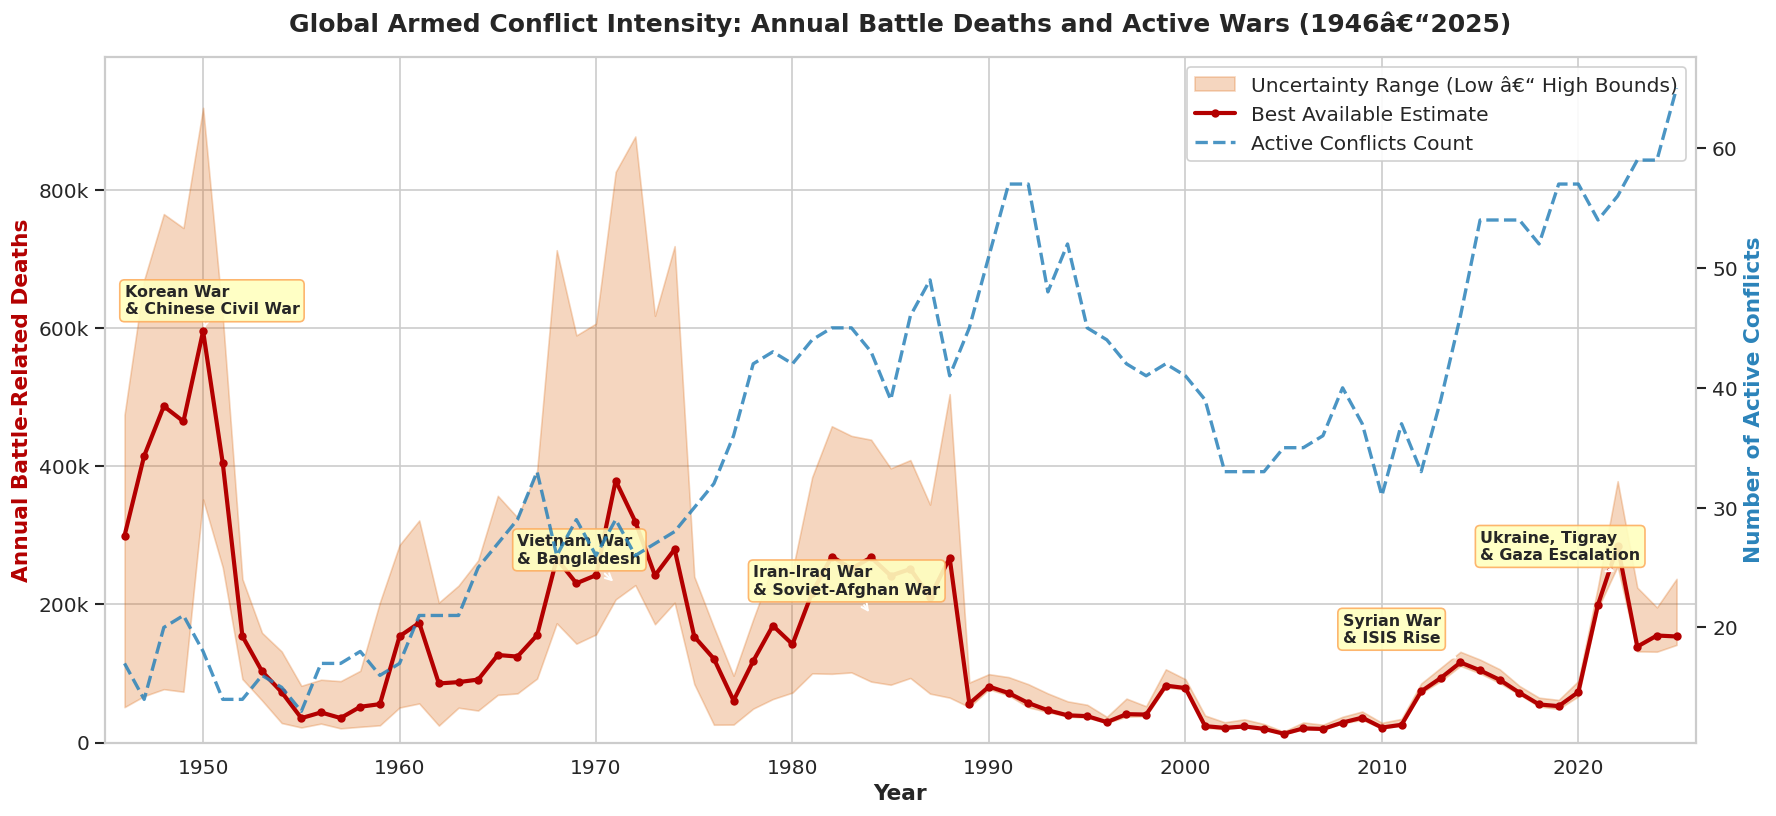

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set overall aesthetic style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Aggregate battle deaths and conflicts annually
yearly_stats = df_combined_all.groupby('year').agg(
    deaths_est=('deaths_estimate', 'sum'),
    deaths_low=('deaths_low', 'sum'),
    deaths_high=('deaths_high', 'sum'),
    n_conflicts=('conflict_id', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 7), dpi=120)

# Uncertainty ribbon (low to high estimates)
ax1.fill_between(
    yearly_stats['year'],
    yearly_stats['deaths_low'],
    yearly_stats['deaths_high'],
    color='#d95f02',
    alpha=0.25,
    label='Uncertainty Range (Low â€“ High Bounds)'
)

# Central best estimate trajectory
ax1.plot(
    yearly_stats['year'],
    yearly_stats['deaths_est'],
    color='#b30000',
    lw=2.5,
    marker='o',
    markersize=4,
    label='Best Available Estimate'
)

# Format primary Y-axis (Casualties)
ax1.set_ylabel('Annual Battle-Related Deaths', fontsize=13, fontweight='bold', color='#b30000')
ax1.set_xlabel('Year', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x/1000):,}k" if x > 0 else "0"))
ax1.set_xlim(1945, 2026)
ax1.set_ylim(0, yearly_stats['deaths_high'].max() * 1.08)

# Secondary Y-axis for number of active conflicts
ax2 = ax1.twinx()
ax2.plot(
    yearly_stats['year'],
    yearly_stats['n_conflicts'],
    color='#2b83ba',
    lw=2,
    linestyle='--',
    alpha=0.85,
    label='Active Conflicts Count'
)
ax2.set_ylabel('Number of Active Conflicts', fontsize=13, fontweight='bold', color='#2b83ba')
ax2.grid(False) # avoid overlapping gridlines

# Annotate historical milestones
annotations = [
    (1950, 596000, "Korean War\n& Chinese Civil War", (-40, 25)),
    (1971, 230000, "Vietnam War\n& Bangladesh", (-50, 30)),
    (1984, 185000, "Iran-Iraq War\n& Soviet-Afghan War", (-60, 30)),
    (2014, 120000, "Syrian War\n& ISIS Rise", (-60, 25)),
    (2022, 245000, "Ukraine, Tigray\n& Gaza Escalation", (-70, 20))
]

for yr, deaths, text, offset in annotations:
    ax1.annotate(
        text,
        xy=(yr, deaths),
        xytext=(yr + offset[0]/10, deaths + offset[1]*1000),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
        fontsize=9.5,
        fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffbf', edgecolor='#fdae61', alpha=0.9)
    )

# Unified legend combining both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, framealpha=0.9)

plt.title('Global Armed Conflict Intensity: Annual Battle Deaths and Active Wars (1946â€“2025)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

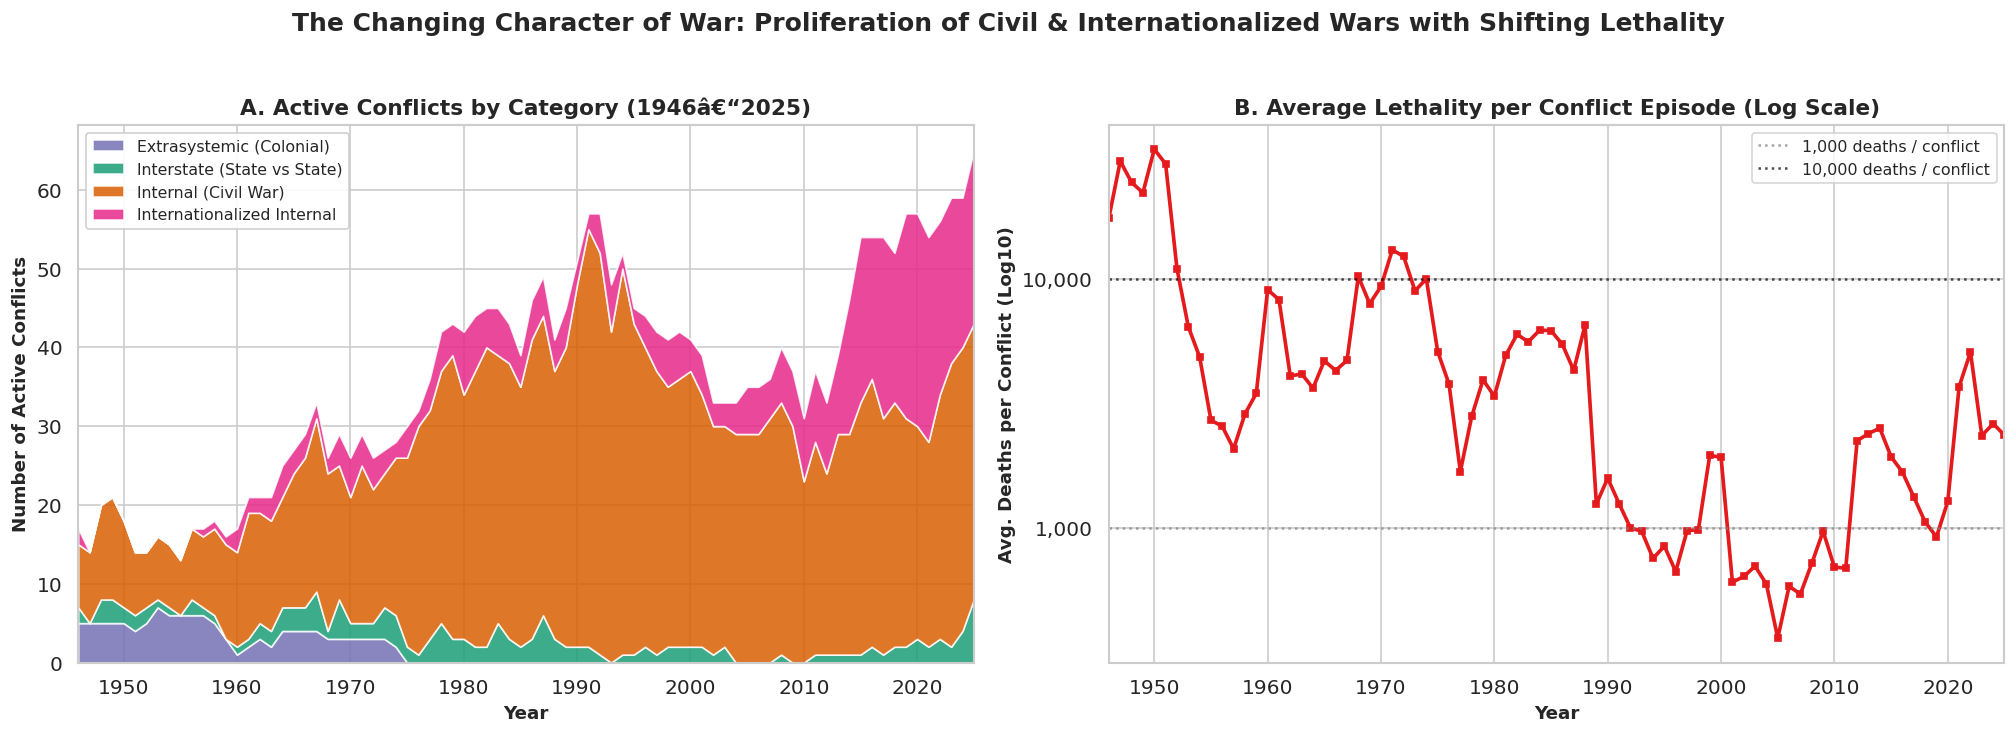

In [13]:
# 1. Map readable conflict type labels
type_map = {
    1: 'Extrasystemic (Colonial)',
    2: 'Interstate (State vs State)',
    3: 'Internal (Civil War)',
    4: 'Internationalized Internal'
}
df_combined_all['type_label'] = df_combined_all['type_of_conflict'].map(type_map)

# Annual count of unique conflicts by type
conflicts_by_type = df_combined_all.groupby(['year', 'type_label'])['conflict_id'].nunique().unstack(fill_value=0)

# Ensure ordered columns
desired_order = ['Extrasystemic (Colonial)', 'Interstate (State vs State)', 'Internal (Civil War)', 'Internationalized Internal']
conflicts_by_type = conflicts_by_type[[c for c in desired_order if c in conflicts_by_type.columns]]

# 2. Compute average lethality per conflict per year
lethality = df_combined_all.groupby('year').agg(
    total_deaths=('deaths_estimate', 'sum'),
    n_conflicts=('conflict_id', 'nunique')
).reset_index()
lethality['deaths_per_conflict'] = lethality['total_deaths'] / lethality['n_conflicts']

# Plotting 2-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6), dpi=120)

# Colors for conflict types
palette = ['#7570b3', '#1b9e77', '#d95f02', '#e7298a']

# Panel A: Stacked area of conflict types
ax1.stackplot(
    conflicts_by_type.index,
    [conflicts_by_type[c] for c in conflicts_by_type.columns],
    labels=conflicts_by_type.columns,
    colors=palette,
    alpha=0.85
)
ax1.set_title('A. Active Conflicts by Category (1946â€“2025)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Active Conflicts', fontsize=11, fontweight='bold')
ax1.set_xlim(1946, 2025)
ax1.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=9.5)

# Panel B: Average Lethality per Conflict (Deaths per Conflict)
ax2.plot(
    lethality['year'],
    lethality['deaths_per_conflict'],
    color='#e41a1c',
    lw=2.2,
    marker='s',
    markersize=3.5
)
ax2.set_yscale('log')
ax2.set_title('B. Average Lethality per Conflict Episode (Log Scale)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Avg. Deaths per Conflict (Log10)', fontsize=11, fontweight='bold')
ax2.set_xlim(1946, 2025)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Add horizontal baseline for reference
ax2.axhline(1000, color='gray', linestyle=':', alpha=0.7, label='1,000 deaths / conflict')
ax2.axhline(10000, color='black', linestyle=':', alpha=0.7, label='10,000 deaths / conflict')
ax2.legend(loc='upper right', frameon=True, fontsize=9.5)

plt.suptitle('The Changing Character of War: Proliferation of Civil & Internationalized Wars with Shifting Lethality', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

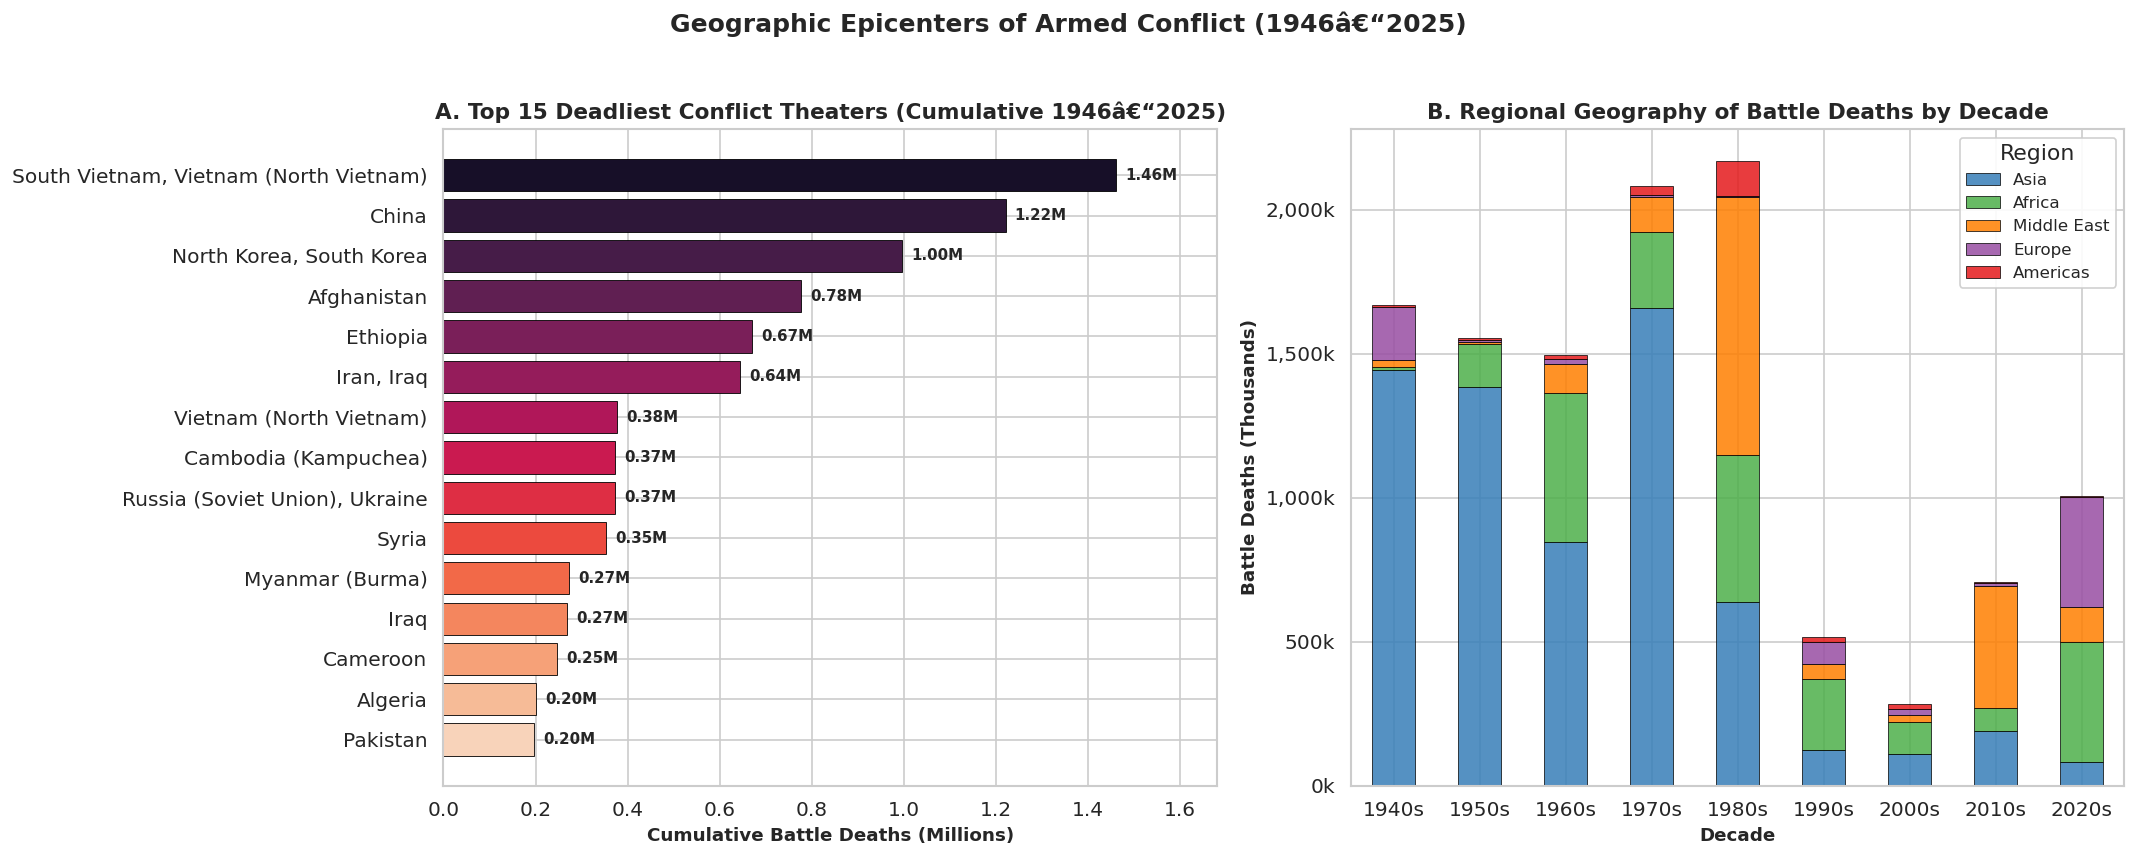

In [14]:
# 1. Top 15 Deadliest Conflict Theaters (Cumulative 1946-2025)
top15 = df_combined_all.groupby('location')['deaths_estimate'].sum().sort_values(ascending=True).tail(15)

# 2. Regional breakdown across decades
# Clean single region assignment
def parse_primary_region(r):
    if pd.isna(r):
        return 'Other/Multi-region'
    first_code = str(r).split(',')[0].strip()
    r_map = {'1': 'Europe', '2': 'Middle East', '3': 'Asia', '4': 'Africa', '5': 'Americas'}
    return r_map.get(first_code, 'Other/Multi-region')

df_combined_all['decade'] = (df_combined_all['year'] // 10) * 10
df_combined_all['region_name'] = df_combined_all['region'].apply(parse_primary_region)

# Pivot: Total Battle Deaths by Decade and Region
decadal_regional = df_combined_all.groupby(['decade', 'region_name'])['deaths_estimate'].sum().unstack(fill_value=0)
decadal_regional = decadal_regional[['Asia', 'Africa', 'Middle East', 'Europe', 'Americas']]

# Create 2-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

# Panel A: Horizontal Bar Chart of Top 15 Locations
colors = sns.color_palette("rocket_r", len(top15))
bars = ax1.barh(top15.index, top15.values / 1e6, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('A. Top 15 Deadliest Conflict Theaters (Cumulative 1946â€“2025)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cumulative Battle Deaths (Millions)', fontsize=11, fontweight='bold')
ax1.set_xlim(0, (top15.max() / 1e6) * 1.15)

for bar in bars:
    w = bar.get_width()
    ax1.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.2f}M", va='center', ha='left', fontsize=9, fontweight='semibold')

# Panel B: Grouped / Stacked Bar Chart of Battle Deaths by Decade across Continents
decadal_norm = (decadal_regional / 1e3) # in Thousands
decade_colors = {'Asia': '#377eb8', 'Africa': '#4daf4a', 'Middle East': '#ff7f00', 'Europe': '#984ea3', 'Americas': '#e41a1c'}

decadal_norm.plot(
    kind='bar',
    stacked=True,
    color=[decade_colors[c] for c in decadal_norm.columns],
    edgecolor='black',
    linewidth=0.5,
    ax=ax2,
    alpha=0.85
)
ax2.set_title('B. Regional Geography of Battle Deaths by Decade', fontsize=13, fontweight='bold')
ax2.set_xlabel('Decade', fontsize=11, fontweight='bold')
ax2.set_ylabel('Battle Deaths (Thousands)', fontsize=11, fontweight='bold')
ax2.set_xticklabels([f"{d}s" for d in decadal_norm.index], rotation=0)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}k"))
ax2.legend(title='Region', frameon=True, framealpha=0.9, fontsize=10)

plt.suptitle('Geographic Epicenters of Armed Conflict (1946â€“2025)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()